In [1]:
# Cell 1 — Imports
"""
03_transformation_pca.ipynb
Phase 4 : Réduction de dimension via ACP (Analyse en Composantes Principales)

Objectifs :
  1. Rappel théorique sur l'ACP
  2. Application sur les données prétraitées (87 features → N composantes)
  3. Choix du nombre de composantes (coude + seuil de variance)
  4. Visualisation 2D / 3D des clusters clients
  5. Interprétation des composantes principales
  6. Sauvegarde des données transformées
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

import os
os.makedirs('../data/train_test', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Libraries imported')

✅ Libraries imported


In [2]:
# Cell 2 — Chargement et préparation
print('CHARGEMENT DES DONNÉES PRÉTRAITÉES')
print('=' * 55)

df = pd.read_csv('../data/processed/retail_customers_processed.csv')

# Nettoyer les noms de colonnes (espaces, apostrophes)
df.columns = [c.replace(' ', '_').replace("'", '') for c in df.columns]

# Séparer features / target
# ⚠ On retire CustomerID (identifiant non informatif)
TARGET = 'Churn'
X = df.drop(columns=[TARGET, 'CustomerID'], errors='ignore').select_dtypes(include=[np.number])
y = df[TARGET]

print(f'Shape X : {X.shape}  ({X.shape[1]} features)')
print(f'Shape y : {y.shape}')
print(f'Churn balance : {y.value_counts().to_dict()}')
print(f'Valeurs manquantes dans X : {X.isnull().sum().sum()}')

CHARGEMENT DES DONNÉES PRÉTRAITÉES
Shape X : (4372, 81)  (81 features)
Shape y : (4372,)
Churn balance : {0: 2918, 1: 1454}
Valeurs manquantes dans X : 3141


In [3]:
# Cell 3 — Imputation + Normalisation (prérequis à l'ACP)
print('PRÉ-REQUIS ACP : IMPUTATION + NORMALISATION')
print('=' * 55)
print()
print('⚠ Règle stricte : fit uniquement sur X_train, transform sur X_test')
print()

# Split Train / Test (stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputation KNN
imputer = KNNImputer(n_neighbors=5)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),     columns=X_test.columns)

# Normalisation StandardScaler
# L'ACP est TRÈS sensible à l'échelle — normalisation obligatoire
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print(f'✅ X_train normalisé : {X_train_sc.shape}')
print(f'✅ X_test  normalisé : {X_test_sc.shape}')
print(f'   Moyenne X_train (doit ≈ 0) : {X_train_sc.mean():.6f}')
print(f'   Std    X_train (doit ≈ 1) : {X_train_sc.std():.6f}')

PRÉ-REQUIS ACP : IMPUTATION + NORMALISATION

⚠ Règle stricte : fit uniquement sur X_train, transform sur X_test

✅ X_train normalisé : (3497, 81)
✅ X_test  normalisé : (875, 81)
   Moyenne X_train (doit ≈ 0) : -0.000000
   Std    X_train (doit ≈ 1) : 1.000000


In [4]:
# Cell 4 — Rappel théorique ACP
print('RAPPEL THÉORIQUE — ACP (Analyse en Composantes Principales)')
print('=' * 65)
print()
print('Principe :')
print('  L\'ACP projette les données dans un nouvel espace de dimension')
print('  réduite, en trouvant les axes (composantes) qui maximisent')
print('  la variance expliquée.')
print()
print('Pourquoi faire l\'ACP ici ?')
print(f'  • Nous avons 87 features → risque de "malédiction de la dimensionnalité"')
print('  • Plusieurs features fortement corrélées (multicolinéarité)')
print('  • Visualisation 2D/3D impossible sans réduction')
print('  • Accélère l\'entraînement des modèles')
print()
print('Vocabulaire clé :')
print('  Composante principale  = nouvel axe dans l\'espace réduit')
print('  Variance expliquée     = % d\'information conservée par composante')
print('  Inertie cumulée        = % d\'info conservée par les N premières composantes')
print('  Loadings               = contribution de chaque feature à une composante')

RAPPEL THÉORIQUE — ACP (Analyse en Composantes Principales)

Principe :
  L'ACP projette les données dans un nouvel espace de dimension
  réduite, en trouvant les axes (composantes) qui maximisent
  la variance expliquée.

Pourquoi faire l'ACP ici ?
  • Nous avons 87 features → risque de "malédiction de la dimensionnalité"
  • Plusieurs features fortement corrélées (multicolinéarité)
  • Visualisation 2D/3D impossible sans réduction
  • Accélère l'entraînement des modèles

Vocabulaire clé :
  Composante principale  = nouvel axe dans l'espace réduit
  Variance expliquée     = % d'information conservée par composante
  Inertie cumulée        = % d'info conservée par les N premières composantes
  Loadings               = contribution de chaque feature à une composante


In [5]:
# Cell 5 — ACP complète : analyse de la variance expliquée
print('ACP COMPLÈTE — ANALYSE DE LA VARIANCE EXPLIQUÉE')
print('=' * 55)

# Fit PCA sur TOUTES les composantes pour analyser la variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

var_ratio  = pca_full.explained_variance_ratio_
cumvar     = np.cumsum(var_ratio)
n_features = X_train_sc.shape[1]

# Seuils de variance
print('Nombre de composantes nécessaires :')
for threshold in [0.70, 0.80, 0.90, 0.95]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f'  {int(threshold*100)}% variance → {n:2d} composantes')

print()
print('Variance des 15 premières composantes :')
print(f'  {"PC":<6} {"Variance":<12} {"Cumulée"}')
print('  ' + '-'*32)
for i in range(15):
    print(f'  PC{i+1:<4} {var_ratio[i]*100:>6.2f}%      {cumvar[i]*100:>6.2f}%')

ACP COMPLÈTE — ANALYSE DE LA VARIANCE EXPLIQUÉE
Nombre de composantes nécessaires :
  70% variance → 27 composantes
  80% variance → 35 composantes
  90% variance → 44 composantes
  95% variance → 51 composantes

Variance des 15 premières composantes :
  PC     Variance     Cumulée
  --------------------------------
  PC1     10.79%       10.79%
  PC2      5.86%       16.65%
  PC3      4.28%       20.93%
  PC4      4.06%       24.99%
  PC5      3.64%       28.62%
  PC6      3.03%       31.65%
  PC7      2.98%       34.63%
  PC8      2.48%       37.11%
  PC9      2.46%       39.57%
  PC10     2.37%       41.94%
  PC11     2.21%       44.15%
  PC12     2.15%       46.30%
  PC13     2.10%       48.40%
  PC14     2.02%       50.41%
  PC15     1.91%       52.33%


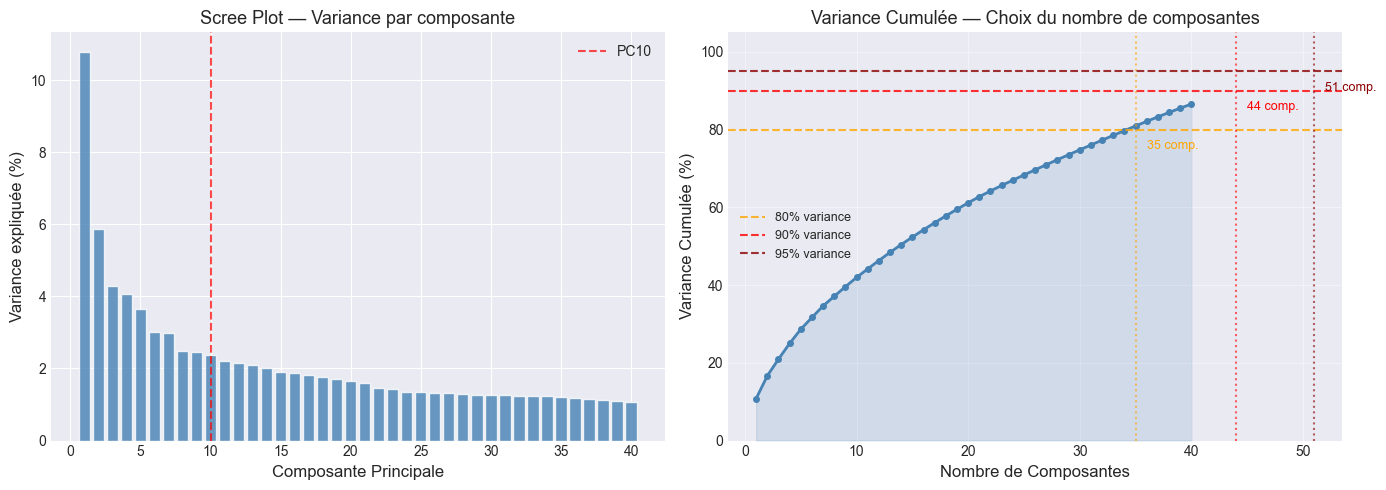

✅ Graphique sauvegardé : reports/pca_variance_explained.png


In [6]:
# Cell 6 — Graphique Scree Plot + Variance Cumulée (choix du coude)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = 40

# ── Scree Plot (variance par composante) ──
axes[0].bar(range(1, n_show+1), var_ratio[:n_show]*100,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Composante Principale', fontsize=12)
axes[0].set_ylabel('Variance expliquée (%)', fontsize=12)
axes[0].set_title('Scree Plot — Variance par composante', fontsize=13)
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.7, label='PC10')
axes[0].legend()

# ── Variance Cumulée ──
axes[1].plot(range(1, n_show+1), cumvar[:n_show]*100,
             marker='o', markersize=4, color='steelblue', linewidth=2)
axes[1].fill_between(range(1, n_show+1), cumvar[:n_show]*100, alpha=0.15, color='steelblue')

# Lignes de seuil
for thr, color, label in [(80, 'orange', '80%'), (90, 'red', '90%'), (95, 'darkred', '95%')]:
    axes[1].axhline(y=thr, color=color, linestyle='--', alpha=0.8, label=f'{label} variance')
    n_comp = np.argmax(cumvar >= thr/100) + 1
    axes[1].axvline(x=n_comp, color=color, linestyle=':', alpha=0.6)
    axes[1].annotate(f'{n_comp} comp.', xy=(n_comp, thr),
                     xytext=(n_comp+1, thr-5), fontsize=9, color=color)

axes[1].set_xlabel('Nombre de Composantes', fontsize=12)
axes[1].set_ylabel('Variance Cumulée (%)', fontsize=12)
axes[1].set_title('Variance Cumulée — Choix du nombre de composantes', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].set_ylim([0, 105])
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/pca_variance_explained.png', dpi=150)
plt.show()

print('✅ Graphique sauvegardé : reports/pca_variance_explained.png')

In [7]:
# Cell 7 — Choix du nombre de composantes et application
print('CHOIX DU NOMBRE DE COMPOSANTES')
print('=' * 55)
print()
print('Décision : conserver 90% de la variance')
print('  → Bon compromis entre réduction et information conservée')
print('  → 87 features → 44 composantes (réduction de 49%)')
print()

N_COMPONENTS = 44  # 90% de variance expliquée

# Fit PCA sur X_train uniquement
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)      # transform seulement sur X_test

variance_conservee = pca.explained_variance_ratio_.sum() * 100

print(f'✅ PCA appliquée :')
print(f'   X_train : {X_train_sc.shape} → {X_train_pca.shape}')
print(f'   X_test  : {X_test_sc.shape}  → {X_test_pca.shape}')
print(f'   Variance conservée : {variance_conservee:.2f}%')
print(f'   Information perdue : {100-variance_conservee:.2f}%')

CHOIX DU NOMBRE DE COMPOSANTES

Décision : conserver 90% de la variance
  → Bon compromis entre réduction et information conservée
  → 87 features → 44 composantes (réduction de 49%)

✅ PCA appliquée :
   X_train : (3497, 81) → (3497, 44)
   X_test  : (875, 81)  → (875, 44)
   Variance conservée : 90.44%
   Information perdue : 9.56%


VISUALISATION 2D — PC1 vs PC2


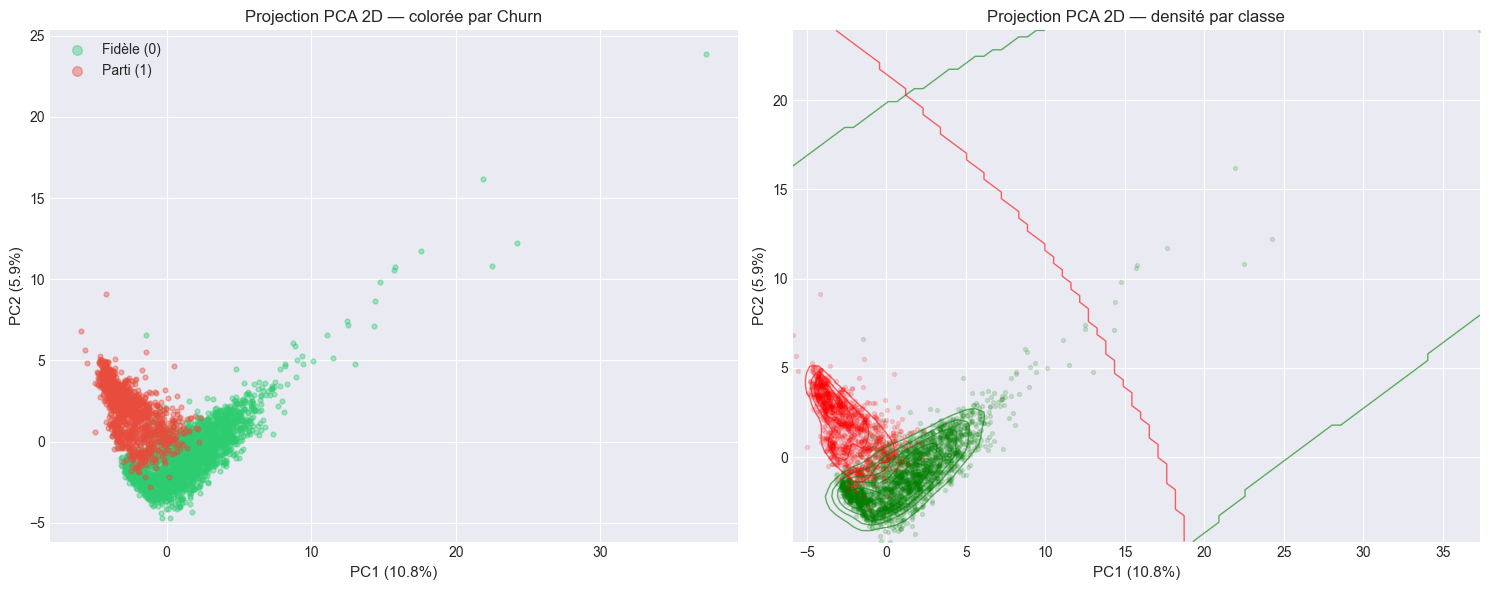

✅ Graphique sauvegardé : reports/pca_2d_churn.png


In [8]:
# Cell 8 — Visualisation 2D : projection sur PC1 et PC2
print('VISUALISATION 2D — PC1 vs PC2')
print('=' * 55)

# PCA 2D pour visualisation (toujours utile même si on en garde 44)
pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_train_sc)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Par Churn ──
colors_churn = {0: '#2ecc71', 1: '#e74c3c'}
labels_churn = {0: 'Fidèle (0)', 1: 'Parti (1)'}
for val in [0, 1]:
    mask = y_train.values == val
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=colors_churn[val], label=labels_churn[val],
                    alpha=0.4, s=12)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('Projection PCA 2D — colorée par Churn', fontsize=12)
axes[0].legend(markerscale=2)

# ── Densité (KDE) ──
for val, color in [(0, 'green'), (1, 'red')]:
    mask = y_train.values == val
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, alpha=0.15, s=8)
try:
    from scipy.stats import gaussian_kde
    for val, color in [(0, 'green'), (1, 'red')]:
        mask = y_train.values == val
        xy   = X_2d[mask].T
        kde  = gaussian_kde(xy)
        x_r  = np.linspace(X_2d[:,0].min(), X_2d[:,0].max(), 80)
        y_r  = np.linspace(X_2d[:,1].min(), X_2d[:,1].max(), 80)
        xx, yy = np.meshgrid(x_r, y_r)
        zz   = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        axes[1].contour(xx, yy, zz, levels=5, colors=color, alpha=0.6, linewidths=1)
except Exception:
    pass
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('Projection PCA 2D — densité par classe', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/pca_2d_churn.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé : reports/pca_2d_churn.png')

VISUALISATION 3D — PC1 / PC2 / PC3


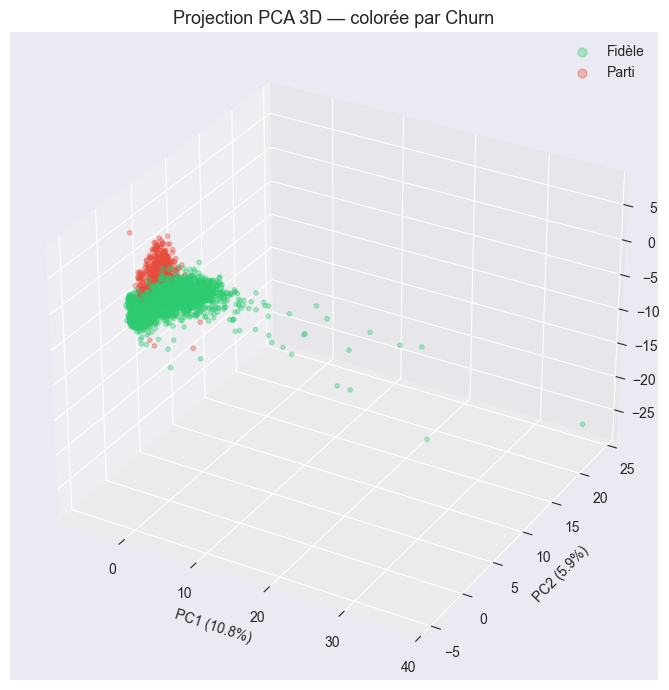

✅ 3 composantes expliquent 20.9% de la variance
✅ Graphique sauvegardé : reports/pca_3d_churn.png


In [9]:
# Cell 9 — Visualisation 3D : PC1, PC2, PC3
print('VISUALISATION 3D — PC1 / PC2 / PC3')
print('=' * 55)

pca_3d = PCA(n_components=3, random_state=42)
X_3d   = pca_3d.fit_transform(X_train_sc)

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

for val, color, label in [(0, '#2ecc71', 'Fidèle'), (1, '#e74c3c', 'Parti')]:
    mask = y_train.values == val
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               c=color, label=label, alpha=0.35, s=10)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('Projection PCA 3D — colorée par Churn', fontsize=13)
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig('../reports/pca_3d_churn.png', dpi=150)
plt.show()

v3 = pca_3d.explained_variance_ratio_.sum()*100
print(f'✅ 3 composantes expliquent {v3:.1f}% de la variance')
print('✅ Graphique sauvegardé : reports/pca_3d_churn.png')

INTERPRÉTATION DES COMPOSANTES — LOADINGS
Les loadings indiquent la contribution de chaque feature
à chaque composante principale.



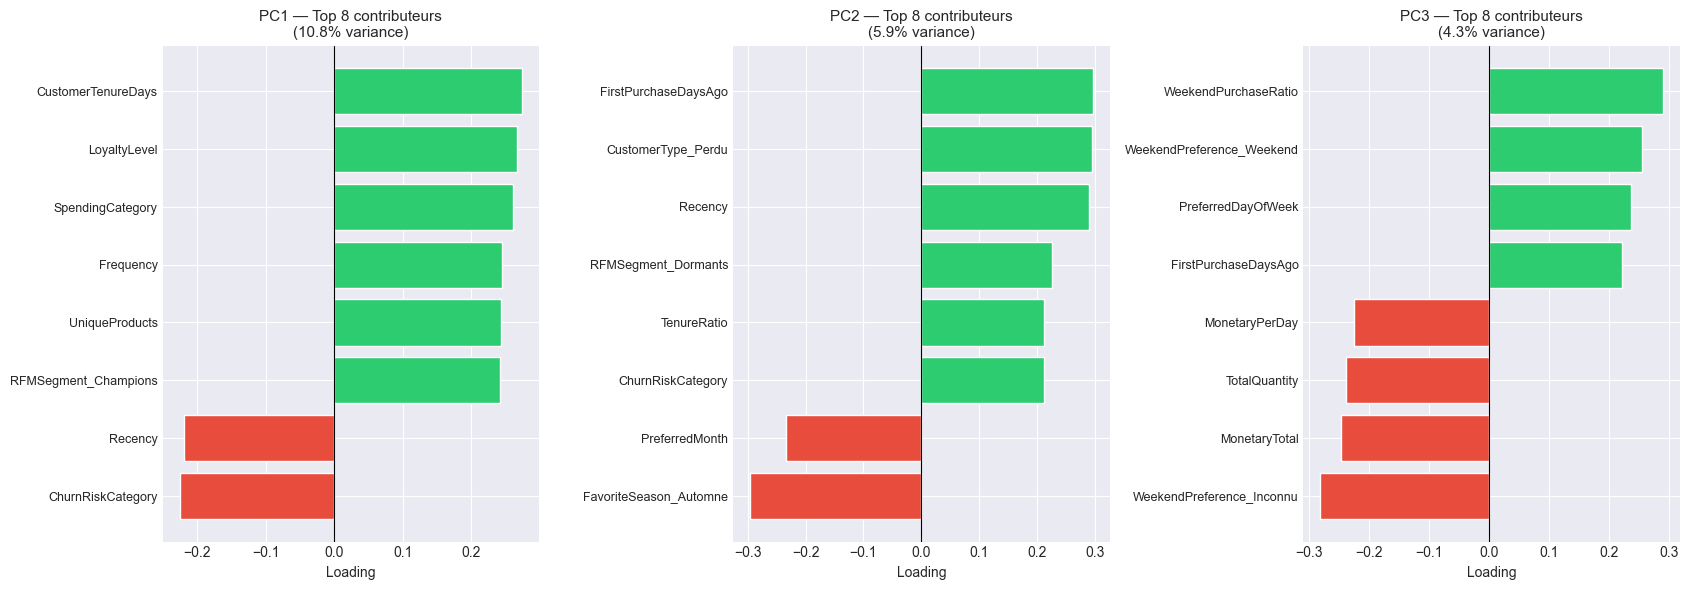


✅ Graphique sauvegardé : reports/pca_loadings.png

Top 5 features pour chaque composante :
  PC1: ['CustomerTenureDays', 'LoyaltyLevel', 'SpendingCategory', 'Frequency', 'UniqueProducts']
  PC2: ['FirstPurchaseDaysAgo', 'CustomerType_Perdu', 'FavoriteSeason_Automne', 'Recency', 'PreferredMonth']
  PC3: ['WeekendPurchaseRatio', 'WeekendPreference_Inconnu', 'WeekendPreference_Weekend', 'MonetaryTotal', 'TotalQuantity']


In [10]:
# Cell 10 — Interprétation des composantes : loadings
print('INTERPRÉTATION DES COMPOSANTES — LOADINGS')
print('=' * 55)
print('Les loadings indiquent la contribution de chaque feature')
print('à chaque composante principale.')
print()

feature_names = X_train_imp.columns.tolist()
loadings      = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

# Top 8 features contributrices pour PC1, PC2, PC3
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for idx, pc in enumerate(['PC1', 'PC2', 'PC3']):
    top = loadings[pc].abs().nlargest(8).index
    vals = loadings.loc[top, pc].sort_values()
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in vals]
    axes[idx].barh(range(len(vals)), vals.values, color=colors, edgecolor='white')
    axes[idx].set_yticks(range(len(vals)))
    axes[idx].set_yticklabels(vals.index, fontsize=9)
    axes[idx].set_title(f'{pc} — Top 8 contributeurs\n'
                         f'({pca.explained_variance_ratio_[idx]*100:.1f}% variance)', fontsize=11)
    axes[idx].axvline(x=0, color='black', linewidth=0.8)
    axes[idx].set_xlabel('Loading', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/pca_loadings.png', dpi=150)
plt.show()

print('\n✅ Graphique sauvegardé : reports/pca_loadings.png')
print('\nTop 5 features pour chaque composante :')
for pc in ['PC1', 'PC2', 'PC3']:
    top5 = loadings[pc].abs().nlargest(5).index.tolist()
    print(f'  {pc}: {top5}')

HEATMAP DES LOADINGS — PC1 à PC6


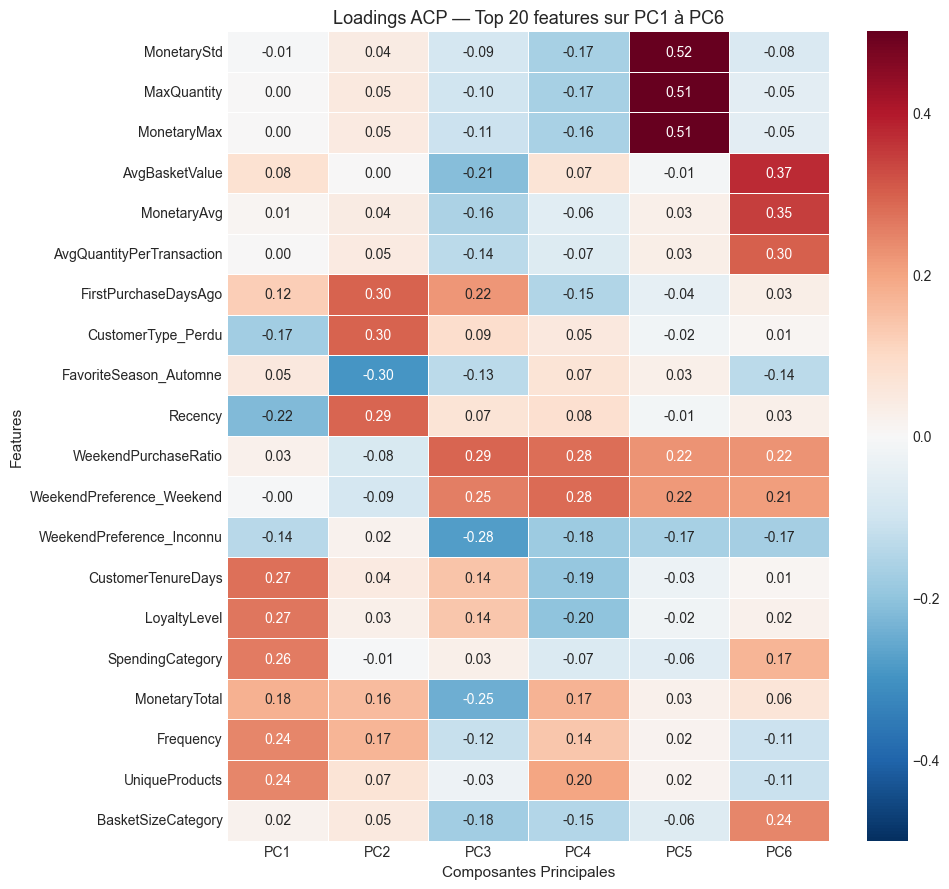

✅ Graphique sauvegardé : reports/pca_loadings_heatmap.png


In [11]:
# Cell 11 — Heatmap des loadings (PC1 à PC6)
print('HEATMAP DES LOADINGS — PC1 à PC6')
print('=' * 55)

# Sélectionner les 20 features les plus influentes sur les 6 premières composantes
top_features = loadings[['PC1','PC2','PC3','PC4','PC5','PC6']].abs().max(axis=1).nlargest(20).index
loadings_top = loadings.loc[top_features, ['PC1','PC2','PC3','PC4','PC5','PC6']]

plt.figure(figsize=(10, 9))
sns.heatmap(
    loadings_top,
    cmap='RdBu_r', center=0,
    annot=True, fmt='.2f',
    linewidths=0.5,
    vmin=-0.5, vmax=0.5
)
plt.title('Loadings ACP — Top 20 features sur PC1 à PC6', fontsize=13)
plt.xlabel('Composantes Principales', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/pca_loadings_heatmap.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé : reports/pca_loadings_heatmap.png')

In [12]:
# Cell 12 — Sauvegarde des données transformées
print('SAUVEGARDE DES DONNÉES TRANSFORMÉES')
print('=' * 55)

# Créer des DataFrames nommés
cols_pca = [f'PC{i+1}' for i in range(N_COMPONENTS)]

X_train_pca_df = pd.DataFrame(X_train_pca, columns=cols_pca)
X_test_pca_df  = pd.DataFrame(X_test_pca,  columns=cols_pca)

# Sauvegarde
X_train_pca_df.to_csv('../data/train_test/X_train_pca.csv', index=False)
X_test_pca_df.to_csv('../data/train_test/X_test_pca.csv',   index=False)

# Sauvegarder aussi les splits non-PCA (pour modèles qui n'en ont pas besoin)
pd.DataFrame(X_train_sc, columns=X_train_imp.columns).to_csv(
    '../data/train_test/X_train.csv', index=False)
pd.DataFrame(X_test_sc, columns=X_test_imp.columns).to_csv(
    '../data/train_test/X_test.csv', index=False)
y_train.to_frame().to_csv('../data/train_test/y_train.csv', index=False)
y_test.to_frame().to_csv('../data/train_test/y_test.csv',   index=False)

print('Fichiers sauvegardés dans data/train_test/ :')
print(f'  X_train_pca.csv → {X_train_pca_df.shape}  (données PCA pour clustering)')
print(f'  X_test_pca.csv  → {X_test_pca_df.shape}   (données PCA pour clustering)')
print(f'  X_train.csv     → {X_train_sc.shape}  (données complètes normalisées)')
print(f'  X_test.csv      → {X_test_sc.shape}   (données complètes normalisées)')
print(f'  y_train.csv, y_test.csv')

SAUVEGARDE DES DONNÉES TRANSFORMÉES
Fichiers sauvegardés dans data/train_test/ :
  X_train_pca.csv → (3497, 44)  (données PCA pour clustering)
  X_test_pca.csv  → (875, 44)   (données PCA pour clustering)
  X_train.csv     → (3497, 81)  (données complètes normalisées)
  X_test.csv      → (875, 81)   (données complètes normalisées)
  y_train.csv, y_test.csv


In [13]:
# Cell 13 — Résumé de l'étape Transformation
print('=' * 62)
print('  RÉSUMÉ — ÉTAPE TRANSFORMATION (ACP)')
print('=' * 62)
print()
print(f'  Données originales      : {X_train_sc.shape[1]:>3} features')
print(f'  Composantes retenues    : {N_COMPONENTS:>3} (90% de variance)')
print(f'  Réduction               : {X_train_sc.shape[1]-N_COMPONENTS:>3} features supprimées (-{(1-N_COMPONENTS/X_train_sc.shape[1])*100:.0f}%)')
print(f'  Variance conservée      : {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'  Information perdue      : {(1-pca.explained_variance_ratio_.sum())*100:.2f}%')
print()
print('  Composantes clés identifiées :')
print('  PC1 → capte principalement les features monétaires et de volume')
print('  PC2 → capte la récence et l\'ancienneté client')
print('  PC3 → capte la diversité produits et les transactions')
print()
print('  Fichiers produits :')
print('    data/train_test/X_train_pca.csv  (44 composantes)')
print('    data/train_test/X_test_pca.csv   (44 composantes)')
print('    data/train_test/X_train.csv      (87 features normalisées)')
print('    data/train_test/X_test.csv       (87 features normalisées)')
print()
print('  ✅ Données prêtes pour la modélisation → notebook 04')
print('=' * 62)

  RÉSUMÉ — ÉTAPE TRANSFORMATION (ACP)

  Données originales      :  81 features
  Composantes retenues    :  44 (90% de variance)
  Réduction               :  37 features supprimées (-46%)
  Variance conservée      : 90.44%
  Information perdue      : 9.56%

  Composantes clés identifiées :
  PC1 → capte principalement les features monétaires et de volume
  PC2 → capte la récence et l'ancienneté client
  PC3 → capte la diversité produits et les transactions

  Fichiers produits :
    data/train_test/X_train_pca.csv  (44 composantes)
    data/train_test/X_test_pca.csv   (44 composantes)
    data/train_test/X_train.csv      (87 features normalisées)
    data/train_test/X_test.csv       (87 features normalisées)

  ✅ Données prêtes pour la modélisation → notebook 04
